Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 100000 interior points...
Found boundary types: ['wall', 'upstream', 'building']
  - Sampling 'wall' (20000 points)...
  - Sampling 'upstream' (20000 points)...
  - Sampling 'building' (20000 points)...
Generating plot...
Domain Bounds: X[560619.6, 561358.9], Y[99683.6, 100382.9]
Plot saved to check_mesh_density.png


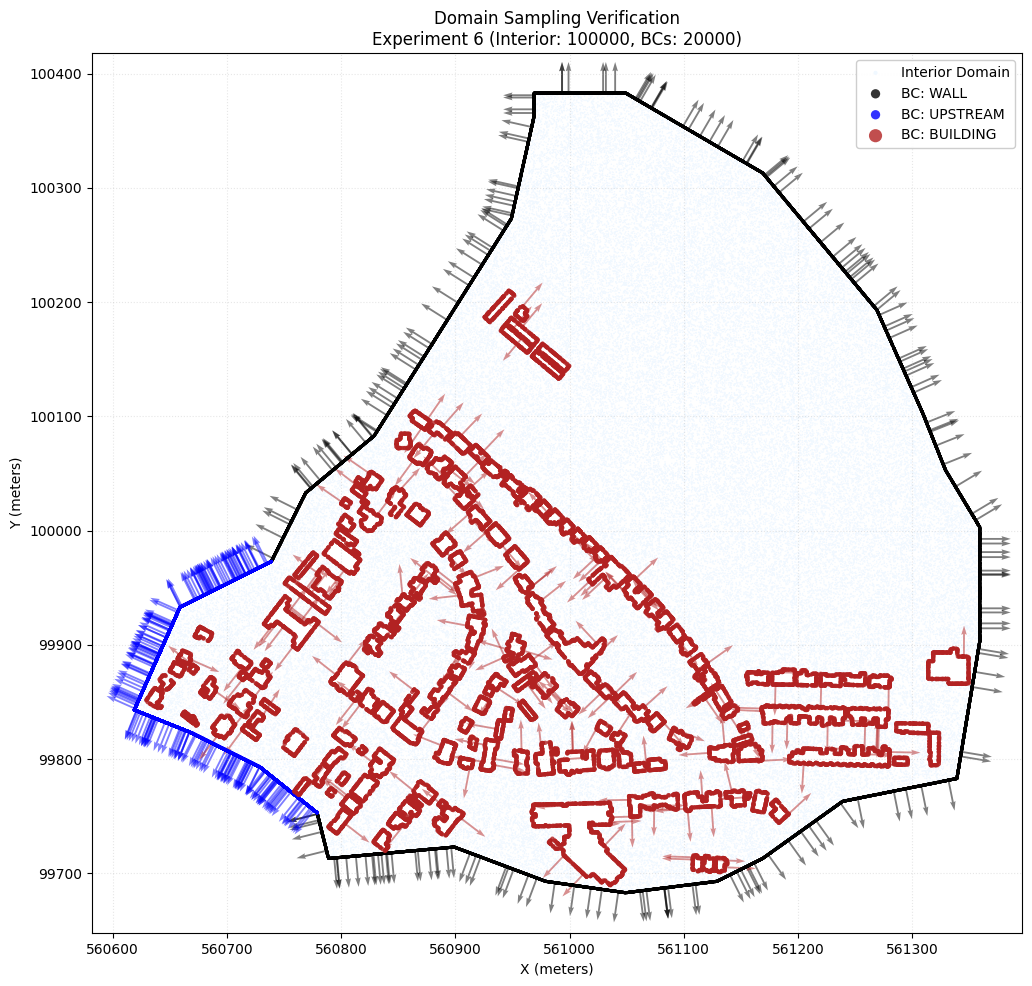

In [10]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# --- Setup Paths ---
# Add project root to path so we can import src
try:
    # Assuming this script is in scripts/ or similar relative to root
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    # Fallback for interactive environments (notebooks/REPL)
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# --- Configuration ---
# Set JAX to use CPU for plotting to avoid OOM on small GPUs/rendering
jax.config.update("jax_platform_name", "cpu")

import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to your artifacts (ensure this matches where you ran the preprocess script)
ARTIFACTS_PATH = os.path.join(project_root, "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz")

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Please run scripts/preprocess_irregular.py first.")
        return

    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    
    # Initialize Sampler
    # The updated IrregularDomainSampler automatically detects keys like 'bc_building', 'bc_upstream'
    try:
        sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    except Exception as e:
        print(f"Failed to initialize sampler: {e}")
        return
    
    # Setup JAX keys
    key = jax.random.PRNGKey(42)
    k_int, k_bnd = jax.random.split(key)

    # --- Sampling Configuration ---
    # High density numbers for "good density" visualization
    N_INTERIOR = 100_000
    N_BOUNDARY = 20_000
    
    # 1. Sample Interior
    print(f"Sampling {N_INTERIOR} interior points...")
    # t_bounds are required by the API but irrelevant for spatial 2D plotting
    interior_pts = sampler.sample_interior(k_int, n_points=N_INTERIOR, t_bounds=(0, 1))
    
    # 2. Sample All Boundaries
    bnd_samples = {}
    available_boundaries = list(sampler.boundaries.keys())
    print(f"Found boundary types: {available_boundaries}")
    
    for label in available_boundaries:
        k_bnd, subkey = jax.random.split(k_bnd)
        print(f"  - Sampling '{label}' ({N_BOUNDARY} points)...")
        # Determine specific density based on label if needed, otherwise uniform
        n_b = N_BOUNDARY
        
        # Sample
        pts = sampler.sample_boundary(subkey, n_points=n_b, t_bounds=(0, 1), boundary_type=label)
        bnd_samples[label] = pts

    # --- Plotting ---
    print("Generating plot...")
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot Interior
    # Use s=0.5 or s=1 with low alpha to visualize density gradients if they exist
    ax.scatter(interior_pts[:, 0], interior_pts[:, 1], 
               s=1, c='aliceblue', edgecolors='none', alpha=1.0, 
               label='Interior Domain', rasterized=True)
    
    # Plot Boundaries with distinct colors
    # Define a color map for common types
    color_map = {
        'wall': 'black',
        'building': 'firebrick',
        'upstream': 'blue',
        'downstream': 'green',
        'inflow': 'blue',
        'outflow': 'green'
    }
    fallback_colors = ['purple', 'orange', 'cyan', 'magenta']
    
    for i, (label, pts) in enumerate(bnd_samples.items()):
        if pts.shape[0] == 0:
            continue
            
        color = color_map.get(label, fallback_colors[i % len(fallback_colors)])
        marker = '.'
        
        # Make buildings stand out
        size = 10 if label == 'building' else 5
        zorder = 10 if label == 'building' else 5
        
        ax.scatter(pts[:, 0], pts[:, 1], 
                   s=size, c=color, label=f"BC: {label.upper()}", 
                   alpha=0.8, edgecolors='none', zorder=zorder)

        # Plot normal vectors for a subset of points (to verify orientation)
        # pts has shape (N, 5) -> [x, y, t, nx, ny]
        if pts.shape[1] >= 5:
            step = max(1, len(pts) // 200) # Plot ~200 arrows per boundary
            subset = pts[::step]
            ax.quiver(subset[:, 0], subset[:, 1], subset[:, 3], subset[:, 4],
                      color=color, scale=30, width=0.002, alpha=0.5)

    ax.set_aspect('equal')
    ax.set_title(f"Domain Sampling Verification\nExperiment 6 (Interior: {N_INTERIOR}, BCs: {N_BOUNDARY})")
    ax.set_xlabel("X (meters)")
    ax.set_ylabel("Y (meters)")
    ax.legend(loc='upper right', framealpha=0.95, markerscale=3)
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # Add coordinates info
    x_min, x_max = interior_pts[:, 0].min(), interior_pts[:, 0].max()
    y_min, y_max = interior_pts[:, 1].min(), interior_pts[:, 1].max()
    print(f"Domain Bounds: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
    
    out_file = "check_mesh_density.png"
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {out_file}")
    plt.show()

if __name__ == "__main__":
    main()

Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
Loading sampler artifacts from: /workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz
  - Registered boundary 'wall': 21 segments
  - Registered boundary 'upstream': 5 segments
  - Registered boundary 'building': 3252 segments
Sampling 50,000 PDE points...
Loading buildings from /workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp...
Generating verification plot...
Number of PDE samples generated: 50000
Sample X range: 560619.88 to 561359.00
Sample Y range: 99683.44 to 100382.80
Verification plot saved to check_pde_voids_fixed.png


/tmp/ipykernel_10610/4121183476.py:75: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="upper right")


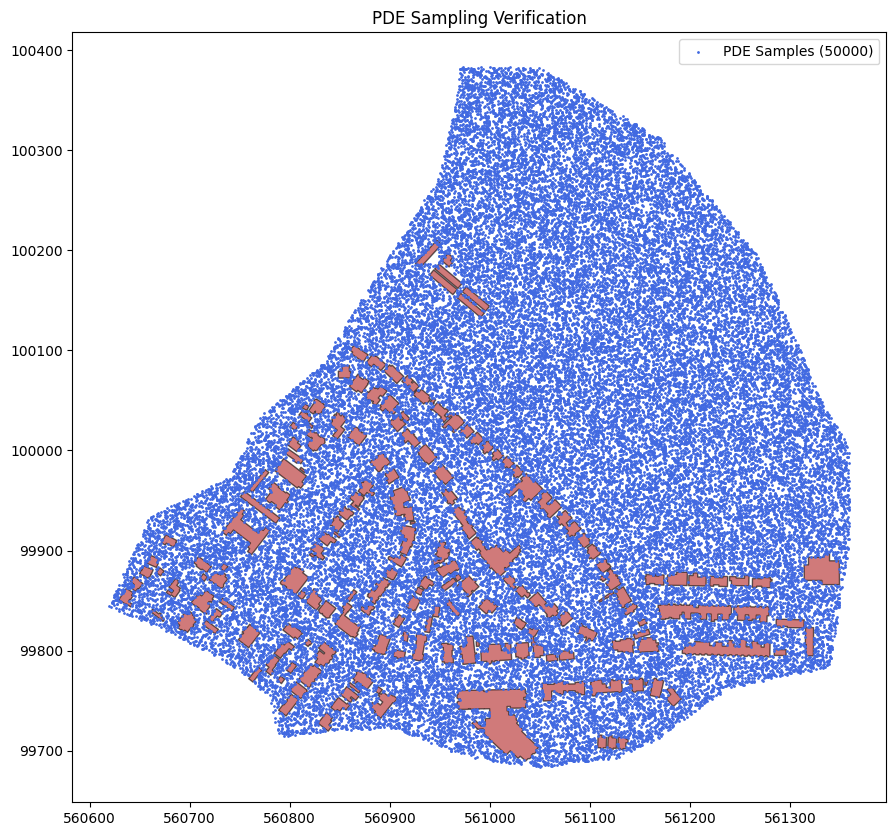

In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import jax
import jax.numpy as jnp
from shapely.geometry import Point

# --- Setup Paths ---
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.config
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# --- CORRECTED PATHS ---
# Using the absolute paths you provided directly
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/experiment_6/domain_artifacts.npz"
BUILDINGS_PATH = "/workspaces/swe-pinn/data/experiment_6/Buildings_cleaned.shp"

def main():
    # 1. Initialize Sampler
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        print("Did you run 'scripts/preprocess_irregular.py' with the --buildings flag yet?")
        return
    
    print(f"Loading sampler artifacts from: {ARTIFACTS_PATH}")
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    # 2. Sample PDE Points (Interior)
    print("Sampling 50,000 PDE points...")
    key = jax.random.PRNGKey(0)
    # Sample interior points (time is irrelevant for this spatial check)
    pde_samples = sampler.sample_interior(key, n_points=50000, t_bounds=(0, 1))
    pde_xy = pde_samples[:, :2] # Extract (x, y)
    
    # 3. Load Buildings for Verification
    if not os.path.exists(BUILDINGS_PATH):
        print(f"Error: Buildings file not found at {BUILDINGS_PATH}")
        return

    print(f"Loading buildings from {BUILDINGS_PATH}...")
    try:
        buildings_gdf = gpd.read_file(BUILDINGS_PATH)
    except Exception as e:
        print(f"Could not load buildings for verification: {e}")
        return

# 4. Plotting Verification
    print("Generating verification plot...")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # A. Plot Buildings (Red Voids)
    buildings_gdf.plot(ax=ax, color='firebrick', alpha=0.6, edgecolor='black', label='Buildings (Obstacles)')
    
    # B. Plot PDE Samples (Dark Blue)
    # Changed from 'aliceblue' to 'blue' and s=0.5 to s=1.0 for visibility
    pts_np = np.array(pde_xy)
    if len(pts_np) > 0:
        ax.scatter(pts_np[:, 0], pts_np[:, 1], s=1.0, c='royalblue', label=f'PDE Samples ({len(pts_np)})')
    else:
        print("WARNING: PDE Sample array is empty!")

    # C. Formatting
    ax.set_title("PDE Sampling Verification")
    ax.set_aspect('equal')
    ax.legend(loc="upper right")
    
    # Print stats to terminal to confirm data exists
    print(f"Number of PDE samples generated: {len(pts_np)}")
    if len(pts_np) > 0:
        print(f"Sample X range: {pts_np[:,0].min():.2f} to {pts_np[:,0].max():.2f}")
        print(f"Sample Y range: {pts_np[:,1].min():.2f} to {pts_np[:,1].max():.2f}")
    
    output_file = "check_pde_voids_fixed.png"
    plt.savefig(output_file, dpi=150)
    print(f"Verification plot saved to {output_file}")
    plt.show()

if __name__ == "__main__":
    main()

Initializing Sampler...
Loading sampler artifacts from: /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz
  - Registered boundary 'wall': 75 segments
  - Registered boundary 'inflow': 1 segments
Found boundaries: ['wall', 'inflow']


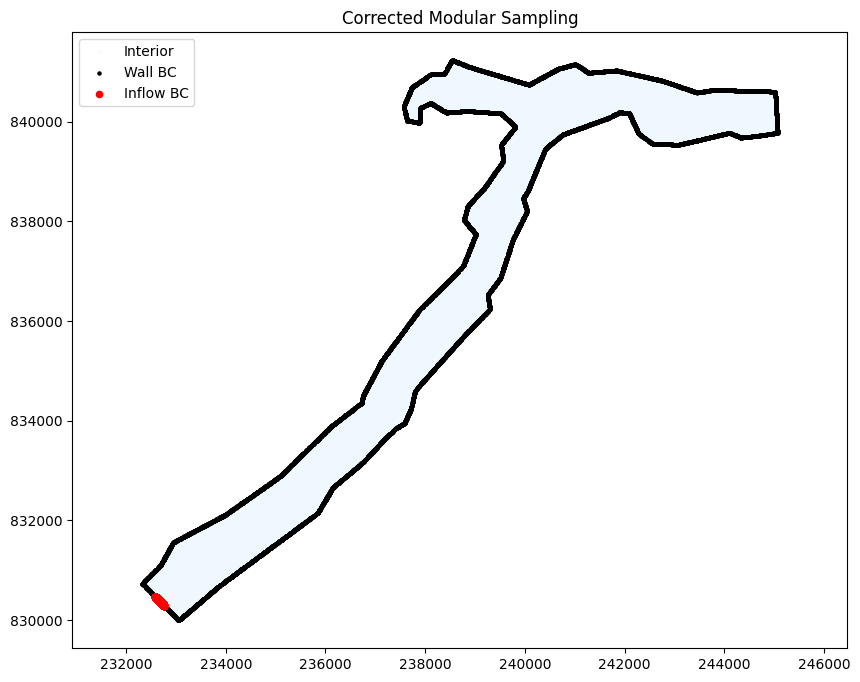

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import jax
import src.config
import jax.numpy as jnp

# Ensure DTYPE is set
src.config.DTYPE = jnp.float32
from src.data import IrregularDomainSampler

# Path to the NEW artifacts (generated by your successful preprocessing run)
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def main():
    print("Initializing Sampler...")
    # Direct load - no compatibility wrappers needed!
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    print(f"Found boundaries: {list(sampler.boundaries.keys())}")

    # Generate samples
    key = jax.random.PRNGKey(42)
    k1, k2, k3 = jax.random.split(key, 3)
    
    # 1. PDE
    pts_pde = sampler.sample_interior(k1, 500000, (0,1))
    
    # 2. Wall (The Domain)
    pts_wall = sampler.sample_boundary(k2, 10000, (0,1), 'wall')
    
    # 3. Inflow (The Polyline)
    pts_inflow = sampler.sample_boundary(k3, 5000, (0,1), 'inflow')
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(pts_pde[:,0], pts_pde[:,1], s=1, c='aliceblue', alpha=0.9, label='Interior')
    plt.scatter(pts_wall[:,0], pts_wall[:,1], s=5, c='black', label='Wall BC')
    plt.scatter(pts_inflow[:,0], pts_inflow[:,1], s=20, c='red', label='Inflow BC')
    
    plt.legend()
    plt.axis('equal')
    plt.title("Corrected Modular Sampling")
    plt.show()
    
if __name__ == "__main__":
    main()

In [17]:
import time
import os
import sys
import jax
import jax.numpy as jnp

# --- 1. Setup Environment ---
# Add project root to path so we can import src
try:
    project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
except NameError:
    project_root = "/workspaces/swe-pinn"

if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Set DTYPE manually before importing data classes
import src.config
src.config.DTYPE = jnp.float32

from src.data import IrregularDomainSampler

# Path to artifacts (Adjust if your file is named differently)
ARTIFACTS_PATH = "/workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz"

def main():
    if not os.path.exists(ARTIFACTS_PATH):
        print(f"Error: Artifacts not found at {ARTIFACTS_PATH}")
        return

    print(f"Loading sampler from {ARTIFACTS_PATH}...")
    sampler = IrregularDomainSampler(ARTIFACTS_PATH)
    
    # --- Configuration for "One Epoch" ---
    N_BATCHES = 100       # How many batches in one epoch
    N_PDE = 50000          # Points per batch
    N_WALL = 10000
    N_INFLOW = 5000
    T_BOUNDS = (0, 10)
    
    # Initialize Random Keys
    key = jax.random.PRNGKey(42)
    
    # ---------------------------------------------------------
    # 2. Define the Sampling Step (Pure Python Function)
    # ---------------------------------------------------------
    def generate_batch(k):
        k1, k2, k3 = jax.random.split(k, 3)
        # Sample Interior
        pde = sampler.sample_interior(k1, n_points=N_PDE, t_bounds=T_BOUNDS)
        # Sample Wall
        wall = sampler.sample_boundary(k2, n_points=N_WALL, t_bounds=T_BOUNDS, boundary_type='wall')
        # Sample Inflow (if exists)
        inflow = sampler.sample_boundary(k3, n_points=N_INFLOW, t_bounds=T_BOUNDS, boundary_type='inflow')
        return pde, wall, inflow

    # ---------------------------------------------------------
    # 3. Define the Jitted Version
    # ---------------------------------------------------------
    # We JIT the function. JAX will compile the random.choice internals into efficient XLA code.
    generate_batch_jitted = jax.jit(generate_batch)

    print(f"\n--- Benchmarking 1 Epoch ({N_BATCHES} batches) ---")
    print(f"Batch Size: {N_PDE} PDE + {N_WALL} Wall + {N_INFLOW} Inflow points")

    # ---------------------------------------------------------
    # Test A: No-JIT (Standard Python Mode)
    # ---------------------------------------------------------
    print("\nRunning NO-JIT Loop...")
    start_time = time.time()
    
    curr_key = key
    for _ in range(N_BATCHES):
        curr_key, subkey = jax.random.split(curr_key)
        # Calling the python function directly
        _ = generate_batch(subkey)
        
    # Block to ensure GPU is finished (though standard mode is mostly sync)
    jax.block_until_ready(_) 
    end_time = time.time()
    time_nojit = end_time - start_time
    print(f"Time (No JIT): {time_nojit:.4f} seconds")

    # ---------------------------------------------------------
    # Test B: Jitted (XLA Compiled Mode)
    # ---------------------------------------------------------
    print("\nRunning JITTED Loop...")
    
    # Warmup (Compile the function first)
    print("  Compiling (Warmup)...")
    curr_key, subkey = jax.random.split(key)
    _ = generate_batch_jitted(subkey)
    jax.block_until_ready(_)
    
    # Actual Timing
    print("  Executing...")
    start_time = time.time()
    
    curr_key = key
    for _ in range(N_BATCHES):
        curr_key, subkey = jax.random.split(curr_key)
        # Calling the compiled function
        _ = generate_batch_jitted(subkey)
        
    jax.block_until_ready(_)
    end_time = time.time()
    time_jit = end_time - start_time
    print(f"Time (JIT):    {time_jit:.4f} seconds")

    # ---------------------------------------------------------
    # Summary
    # ---------------------------------------------------------
    print("\n--- Results ---")
    print(f"Speedup Factor: {time_nojit / time_jit:.2f}x")
    print("Conclusion: " + ("JIT is working properly." if time_jit < time_nojit else "Something is wrong (JIT is slower)."))

if __name__ == "__main__":
    main()

Loading sampler from /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz...
Loading sampler artifacts from: /workspaces/swe-pinn/data/benchmark_test_5/domain_artifacts.npz
  - Registered boundary 'wall': 74 segments
  - Registered boundary 'inflow': 1 segments

--- Benchmarking 1 Epoch (100 batches) ---
Batch Size: 50000 PDE + 10000 Wall + 5000 Inflow points

Running NO-JIT Loop...
Time (No JIT): 0.4079 seconds

Running JITTED Loop...
  Compiling (Warmup)...
  Executing...
Time (JIT):    0.0140 seconds

--- Results ---
Speedup Factor: 29.16x
Conclusion: JIT is working properly.


In [9]:
import os
import sys
import jax
import jax.numpy as jnp
from flax.core import FrozenDict
import yaml

# 1. Setup Path to 'src'
# Assuming the notebook is in 'swe-pinn/notebook/' and src is in 'swe-pinn/src'
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
import src.models as models

# 2. Load Configuration
config_path = "../configs/benchmark_test_5.yaml" 
print(f"Loading config from: {config_path}")
cfg = load_config(config_path)

# --- FIX: INJECT MISSING DOMAIN PARAMETERS ---
# These are usually calculated from the mesh file at runtime.
# For a model summary, we can set them to 1.0 or representative values.
if 'domain' not in cfg: cfg['domain'] = {}
cfg['domain']['lx'] = 1.0
cfg['domain']['ly'] = 1.0
cfg['domain']['t_final'] = 1.0
cfg['domain']['x_min'] = 0.0
cfg['domain']['y_min'] = 0.0

# 3. Initialize the Model
model_name = cfg['model']['name']
print(f"Initializing Model: {model_name}")

try:
    model_class = getattr(models, model_name)
except AttributeError:
    raise ValueError(f"Model '{model_name}' not found in src.models")

rng = jax.random.PRNGKey(0)
frozen_config = FrozenDict(cfg)

# Initialize
# Input shape (1, 3) represents (x, y, t)
model, params_container = models.init_model(model_class, rng, frozen_config)
params = params_container['params']

# 4. Generate Parameter Summary
def count_params(params):
    return sum(x.size for x in jax.tree_util.tree_leaves(params))

total_params = count_params(params)

print("\n" + "="*40)
print(f" MODEL SUMMARY: {model_name}")
print("="*40)
print(f"Total Parameters: {total_params:,}")
print("-" * 55)
print(f"{'Layer / Parameter':<30} | {'Shape':<15} | {'Count':<10}")
print("-" * 55)

leaves, _ = jax.tree_util.tree_flatten_with_path(params)

for path, param in leaves:
    # Construct name from path
    name_parts = []
    for p in path:
        if hasattr(p, 'key'):
            name_parts.append(str(p.key))
        elif hasattr(p, 'idx'):
            name_parts.append(str(p.idx))
        else:
            name_parts.append(str(p))
            
    name = "/".join(name_parts)
    print(f"{name:<30} | {str(param.shape):<15} | {param.size:<10,}")

print("="*55)

Loading config from: ../configs/benchmark_test_5.yaml
Initializing Model: DGMNetwork

 MODEL SUMMARY: DGMNetwork
Total Parameters: 1,332,995
-------------------------------------------------------
Layer / Parameter              | Shape           | Count     
-------------------------------------------------------
DGMLayer_0/Ug/bias             | (256,)          | 256       
DGMLayer_0/Ug/kernel           | (3, 256)        | 768       
DGMLayer_0/Uh/bias             | (256,)          | 256       
DGMLayer_0/Uh/kernel           | (3, 256)        | 768       
DGMLayer_0/Ur/bias             | (256,)          | 256       
DGMLayer_0/Ur/kernel           | (3, 256)        | 768       
DGMLayer_0/Uz/bias             | (256,)          | 256       
DGMLayer_0/Uz/kernel           | (3, 256)        | 768       
DGMLayer_0/Wg/kernel           | (256, 256)      | 65,536    
DGMLayer_0/Wh/kernel           | (256, 256)      | 65,536    
DGMLayer_0/Wr/kernel           | (256, 256)      | 65,536    
DGM

In [15]:
import os
import sys
import jax
import jax.numpy as jnp
from flax.core import FrozenDict
import pandas as pd
import yaml

# 1. Setup
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import load_config
import src.models as models

# 2. Load Config & Init Model
config_path = "../configs/benchmark_test_5.yaml" 
cfg = load_config(config_path)
if 'domain' not in cfg: cfg['domain'] = {}
cfg['domain'].update({'lx': 1.0, 'ly': 1.0, 't_final': 1.0, 'x_min': 0.0, 'y_min': 0.0})

model_name = cfg['model']['name']
model_class = getattr(models, model_name)
rng = jax.random.PRNGKey(0)
model, params_container = models.init_model(model_class, rng, FrozenDict(cfg))
params = params_container['params']

# 3. Pure Python "Graph" Visualization
def print_ascii_graph(params, model_name):
    print(f"\n MODEL FLOWCHART: {model_name}")
    print(" " + "="*50)
    
    # --- Input Node ---
    current_dim = 3 # (x, y, t)
    print(f"  [ Input ]")
    print(f"      | (x, y, t)")
    print(f"      v   dim: {current_dim}")

    # --- Fourier Features (Optional) ---
    if 'fourier_features' in params:
        B = params['fourier_features']['B'] # Shape (input, hidden/2)
        out_dim = B.shape[1] * 2
        print(f"  [ Fourier Features ]")
        print(f"      | Sin/Cos Projection")
        print(f"      v   dim: {out_dim}")
        current_dim = out_dim
    
    # --- Hidden Layers ---
    # Sort keys to ensure correct order (dense_layers_0, dense_layers_1...)
    layer_keys = [k for k in params.keys() if 'dense' in k or 'layers' in k]
    
    def get_layer_idx(key):
        parts = key.split('_')
        for p in parts:
            if p.isdigit(): return int(p)
        return 9999
    layer_keys.sort(key=get_layer_idx)
    
    for i, key in enumerate(layer_keys):
        kernel = params[key]['kernel']
        in_d, out_d = kernel.shape
        
        # Verify connection
        conn_str = "OK" if in_d == current_dim else f"MISMATCH ({current_dim}!={in_d})"
        
        box = f"[ Hidden Layer {i} ]"
        details = f"Dense ({in_d} -> {out_d}) | Tanh"
        
        print(f"  {box}")
        print(f"      | {details}")
        if conn_str != "OK":
             print(f"      ! CONNECTION ERROR: {conn_str}")
        print(f"      v   dim: {out_d}")
        
        current_dim = out_d

    # --- Output Layer ---
    if 'output_layer' in params:
        kernel = params['output_layer']['kernel']
        in_d, out_d = kernel.shape
        
        print(f"  [ Output Layer ]")
        print(f"      | Dense ({in_d} -> {out_d}) | Linear")
        print(f"      v   dim: {out_d}")
        print(f"  ( h, hu, hv )")
        
    print(" " + "="*50)

# Run it
print_ascii_graph(params, model_name)


 MODEL FLOWCHART: DGMNetwork
  [ Input ]
      | (x, y, t)
      v   dim: 3
  [ Output Layer ]
      | Dense (256 -> 3) | Linear
      v   dim: 3
  ( h, hu, hv )
